# Research Notebook 2
## Nikka Pakhomova
## Date: March 2nd-8th 2026

# 1: Experience
## Activities done since the last research journal: 

- Wrote 3 different codes for Gastaldello et al.'s <font color=blue>[1]</font> data:
    - wrote a .ipynb code (using my classmates temperature profile fitting code) to solve an ODE to find the gas density profile, calculated the projected gas density and the reduced $\chi^2$ to compare the projected gas density from the ODE solver to the observed projected gas density from Gastaldello et al.'s paper. 
    - turned the previously mentioned code for solving the ODE into a class called gas.py that uses the temperature.py class made by my classmates.
    - wrote an example of a code for how to use the class.
- Attended weekly group meetings to show our progress and compare our results and plots with the other members of the group.

#### Activity due for Monday March 9th:
- Choose one of the galaxies from Gastaldello's paper and write another code implementing a first trial of MCMC (Markov Chain Monte Carlo) and plotting the log_likelihood.

## Motivation:

First, we had to find the best fitting equation for the temperature profiles. 
After having found the best fitting equation, we had to find dT/dr and use both to solve the ODE to find the gas density. The motivation to find the gas density is to project it and be able to compare it to the observed data and plots from Gastaldello's paper <font color=blue>[1]</font> to check the accuracy of our ODE equation for finding rhe gas density. 

The motivation for this is using different temperature fitting models and a different ODE for gas density and comparing it to Gastaldello et al.'s findings and plots. 

# 2: What? (What happened?)

For the ODE solver code:

In our weekly meetings, Dr. Tulin gaves us a differential equation that we had to solve to find the gas density $\rho_{gas}$. 
$$\frac{d\rho_{gas}}{dr} \cdot \frac{1}{\rho_{gas}} + \frac{dT_{gas}}{dr} \cdot \frac{1}{T_{gas}(r)} = - \frac{G \cdot m_{gas} \cdot M_{tot}(r)}{k_B \cdot T_{gas}(r) \cdot r^2}$$

$ T_{gas}(r)$ was determined from the best fitting temperature profiles and the derivative $\frac{dT_{gas}}{dr}$ was calculated analytically.
We chose to work with 2 equations. Eq. 3 from Humphrey et al.'s <font color=blue>[2]</font> paper and equation 6 from Vikhlinin et al.'s paper <font color=blue>[5]</font>.
We were divided into two groups to use each of the equations. My group had to use equation 6 from Vikhlinin et al.'s paper:

$$T(r) = T_0 \cdot t_{\mathrm{outer}}(r) \cdot t_{\mathrm{cool}}(r)$$

where:

$$t_{\mathrm{outer}}(r) = \frac{1}{\left(1 + \left(\frac{r}{r_t}\right)^2 \right)^{0.3}}$$
$$t_{\mathrm{cool}}(r) = \frac{\left(\frac{r}{r_{\mathrm{cool}}}\right)^{a_{\mathrm{cool}}} + T_{\min}/T_0}{\left(\frac{r}{r_{\mathrm{cool}}}\right)^{a_{\mathrm{cool}}} + 1}$$

where $r_{cool}$, $T_{min}$, $a_{cool}$, $r_t$ and $T_0$ are fitted parameters

After my partner fitted every parameter for each galaxy of Gastaldello et al.'s paper and defined it in the temperature.py class, I used it to develop the ODE solver code. First, the code calulates the mass of the galaxy using equation 3 from Hernquist's paper <font color=blue>[3]</font>:
$$ M_{star}(r) = (\Upsilon \cdot L_k) \cdot \frac{r^2}{(r+(\frac{R_{eff}}{1.8153})^2}$$

where $\Upsilon$ is the stellar mass-to-light ratio set at 0.8, $L_k$ is the luminosity and $R_{eff}$ is the effective radius.
And for the dark matter mass, we are using the Jeans spherical model <font color=blue>[4]</font> enclosed mass function: profile.M_encl(r)

It adds them to obtain the total enclosed mass of the galaxy and then using the ODE and the temperature profile, it finds $\rho_{gas}$. From then, Dr. Tulin provided an equation for finding the projected gas density squared along a line of sight: 
$$Proj(R) = \int_{R}^{r_{\max}} \frac{2r}{\sqrt{r^2 - R^2}}\, \rho_{\mathrm{gas}}(r)^2 \, dr$$

And from this we could finally compare our model to Gastaldello et al.'s <font color=blue>[1]</font> paper with a reduced $\chi^2$ calculation. It compares the observed projected gas density from Gastadello et al.'s paper with our projected gas density model based on our ODE solver. 

The code was then turned into a class called gas.py and the input parameters (fit them later) are: $r_m$ (matching radius <font color=blue>[4]</font>), $M_{200}$, c, $r_0$, $r_{max}$, $\rho_0$.

Here's the ODE solver and projected gas density part of the code:

In [ ]:
def _build_mass_model(self, rm, M200, c):
    AC_inputs = {"AC_prescription": "Cautun", 'M_b':self.M_stars}
    profile = jeans.spherical(rm, M200, c, Phi_b=lambda r, th=None: self.Phi_stars(r), **AC_inputs)
    M_DM = lambda r: profile.M_encl(r)
    M_tot = lambda r: self.M_stars(r) + M_DM(r)
    return profile, M_DM, M_tot

def solve_rho_gas(self, rm, M200, c, r0, rmax, rho0, npts=500):
    profile, M_DM, M_tot = self._build_mass_model(rm, M200, c)
    mu = self.mu
    r_eval = np.logspace(np.log10(r0), np.log10(rmax), npts)
    # Create interpolating function for fast evaluation of total mass function
    log_M_tot_interp = InterpolatedUnivariateSpline(np.log(r_eval), np.log(M_tot(r_eval)), k=1, ext=2)
    M_tot_interp = lambda r: np.exp(log_M_tot_interp(np.log(r)))
        
    def rhs(r, y):
        T = self.T(r)
        dT = self.dT_dr(r)
        M = M_tot_interp(r)
        dlnrho_dr = -(dT / T) - (G * mu * M) / (T * r**2)
        return [dlnrho_dr]
        
    sol = solve_ivp(rhs, (r_eval[0], r_eval[-1]), [np.log(rho0)], t_eval=r_eval, rtol=1e-6, atol=1e-10, dense_output=True,)
    return sol

def rho_gas(self, r, sol):
    return np.exp(sol.sol(r))[0]

def projected_rho_gas(self, R_vals, sol, rmax, cgs=True):
    MSUN_G = 1.989e33          # grams per solar mass
    KPC_CM = 3.08568e21        # cm per kpc
    rho_func = lambda r: self.rho_gas(r, sol)
    
    def _proj_integrand(r, R):
        return 2.0 * r / np.sqrt(r**2 - R**2) * rho_func(r)**2

    def _proj_single(R):
        eps = 1e-6
        return quad(_proj_integrand, R + eps, rmax, args=(R,), limit=500)[0]

    R_vals = np.atleast_1d(R_vals)
    proj = np.array([_proj_single(R) for R in R_vals])
    if cgs:
        proj *= MSUN_G**2 / KPC_CM**5
    return proj

And here's the $\chi^2$ calculation:

In [ ]:
    def chi_squared(self, R_obs, proj_obs, sigma_obs, sol, rmax, n_params=4):
        R_obs = np.atleast_1d(R_obs)
        proj_obs = np.atleast_1d(proj_obs)
        sigma_obs = np.atleast_1d(sigma_obs)
        proj_model = self.projected_rho_gas(R_obs, sol, rmax, cgs=False)
        dof = len(R_obs) - n_params
        if dof <= 0:
            raise ValueError(f"Degrees of freedom must be > 0: got {len(R_obs)} data points "f"and {n_params} free parameters.")
        chi2 = np.sum((proj_obs - proj_model)**2 / sigma_obs**2)
        chi2_red = chi2 / dof
        return chi2, chi2_red, dof

Then we plotted our model and the observed projected gas density from Gastaldello et al.'s paper to compare the two models. 

# 3: So what? (What does it mean?)

I chose to solve the ODE by first solving for $\ln(\rho_{gas})$ and then exponentiating the result so that the function will be smoother and will always stays positive. 
We first plotted the gas profile density for a few of the galaxies to check if the code worked. Here's an example of one of the galaxies:

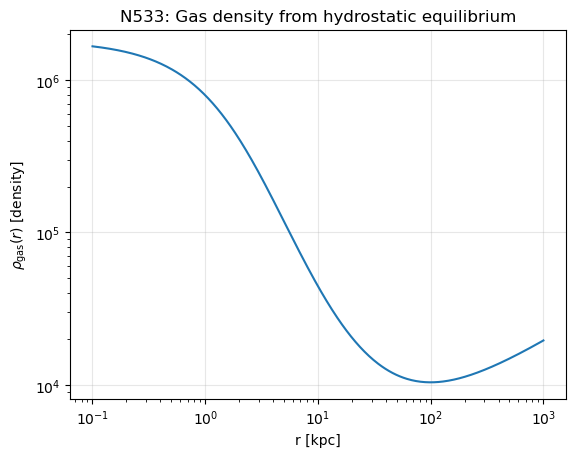

_**Figure 1**: Plot of the gas density profile obtained from the ODE for one system: N533_

Clearly, gas density isn't supposed to increase at larger radii and after analyzing my result, I deduced that the rise of the curve is due to the derivative of the temperature profile. This particular temperature equation from Vikhlinin's paper has a derivative that decreases too quickly at large radii and therefore the sign flips and the curve increases again. The good thing is that we don't have to worry about this increase for our galaxies since all of the Gastaldello et al.'s radius data ends right before the curves rise. 

For the projected gas density, I added an option to the code for changing the units when needed. If cgs=True, the units are changed to $g^2 \cdot cm^{-5}$, if cgs=False the units are kept as $M_{sol}^2 \cdot kpc^{-5}$. The plots on Gastaldello et al.'s paper have the units in $g^2 \cdot cm^{-5}$ but the data is in $M_{sol}^2 \cdot kpc^{-5}$  <font color=blue>[1]</font>. So, we plotted the projected gas density from our model against the Gastaldello et al.'s data in $M_{sol}^2 \cdot kpc^{-5}$ so we could compare them:

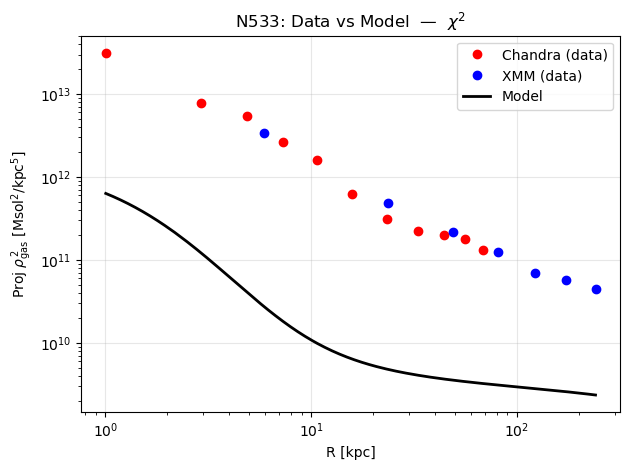

_**Figure 2**: Plot of the projected gas density squared obtained from our model and the observed projected gas density for one system: N533_

The reduced $\chi^2$ for this system was 315.3

Even thought our curve seems to be wrong, when we plot only our model in $g^2 \cdot cm^{-5}$ and compare the shape of the curve to the paper's plots, our model seems to be in agreement. The only difference is on the y-axis numbers. Our model seems to be an order of 10th lower (i.e. the observed data goes from $10^{-28}$ to $10^{-31}$ whereas our model goes from $10^{-29}$ to $10^{-32}$). This is visible on Figure 2: our model curve is lower than the observed one but they have the same shape.  

# 4. Now what? (What's next?)

Now that the gas.py class works and has all the elements we need, we want to try to implement Markov Chain Monte Carlo (MCMC) methods to our galaxies so we can find the best fit for the free input parameters. Each member of the group 

# 5. Bibliography

1. Gastaldello, F., Buote, D. A., Humphrey, P. J., Zappacosta, L., Bullock, J. S., Brighenti, F., & Mathews, W. G. (2007). *Probing the dark matter and gas fraction in relaxed galaxy groups with X-ray observations from Chandra and XMM-Newton.* The Astrophysical Journal. https://arxiv.org/pdf/astro-ph/0610134

2. Humphrey, P. J., Buote, D. A., Gastaldello, F., Zappacosta, L., Bullock, J. S., Brighenti, F., & Mathews, W. G. (2006). A Chandra view of dark matter in early-type galaxies. The Astrophysical Journal. https://arxiv.org/pdf/astro-ph/0601301

3. Hernquist, L., *An Analytical Model for Spherical Galaxies and Bulges*, The Astrophysical Journal, https://ui.adsabs.harvard.edu/link_gateway/1990ApJ...356..359H/ADS_PDF

4. Bautista, Y. F., Robertson, A., Sagunski, L., Smith-Orlik, A., & Tulin, S. (2025). *Jeans model for the shapes of self-interacting dark matter halos.* arXiv:2511.10765. https://arxiv.org/abs/2511.10765

5. Vikhlinin, A., Kravtsov, A., Forman, W., Jones, C., Markevitch, M., Murray, S. S., & Van Speybroeck, L. (2006). *Chandra sample of nearby relaxed galaxy clusters: Mass, gas fraction, and mass–temperature relation.* The Astrophysical Journal. https://arxiv.org/abs/astro-ph/0507092